In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


Step 1: Understanding the Problem and Setting Up

In [2]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


Step 2: Loading the Data

In [3]:
# Step 2: Load the Mushroom Dataset

print("=" * 60)
print("LOADING DATASET FROM KAGGLE COMPETITION")
print("=" * 60)

# Define the correct paths
base_path = '/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/'

# Check if we're on Kaggle
if os.path.exists('/kaggle/input'):
    print("✓ Running on Kaggle platform")
    train_path = base_path + 'train.csv'
    test_path = base_path + 'test.csv'
    sample_path = base_path + 'sample_submission.csv'
else:
    print(" Running locally - please adjust paths")
    train_path = 'train.csv'
    test_path = 'test.csv'
    sample_path = 'sample_submission.csv'

# Load the data
try:
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)
    sample_submission = pd.read_csv(sample_path)
    
    print(f"\n Training data: {train_data.shape[0]} rows, {train_data.shape[1]} columns")
    print(f" Test data: {test_data.shape[0]} rows, {test_data.shape[1]} columns")
    print(f" Sample submission: {sample_submission.shape[0]} rows")
    
except Exception as e:
    print(f"\n Error loading data: {e}")

# Display basic info
print("\n" + "=" * 60)
print("DATA OVERVIEW")
print("=" * 60)

print("\nFirst 5 rows of training data:")
display(train_data.head())

print("\nTraining data info:")
train_data.info()

print("\nTarget variable distribution:")
print(train_data['class'].value_counts())

print("\nTarget percentages:")
print((train_data['class'].value_counts(normalize=True) * 100).round(2))

LOADING DATASET FROM KAGGLE COMPETITION
✓ Running on Kaggle platform

 Training data: 7000 rows, 26 columns
 Test data: 1124 rows, 25 columns
 Sample submission: 1124 rows

DATA OVERVIEW

First 5 rows of training data:


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e



Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   

Step 3: Identify Data Types of Different Columns

In [4]:
# Step 3: Identify Data Types of Different Columns (COMPLETE FIXED VERSION)

print("=" * 60)
print("IDENTIFYING COLUMN DATA TYPES")
print("=" * 60)

# Identify data types
object_columns = train_data.select_dtypes(include=['object']).columns.tolist()
numerical_columns = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove 'class' from features list if present
if 'class' in object_columns:
    object_columns.remove('class')
    print("✓ Removed 'class' from feature columns (it's our target)")

print(f"\n CATEGORICAL COLUMNS: {len(object_columns)} columns")
print("-" * 50)

# Display first 10 categorical columns (to keep output manageable)
display_cols = object_columns[:10]
for col in display_cols:
    unique_values = train_data[col].nunique()
    # Convert dtype to string to avoid formatting error
    dtype_str = str(train_data[col].dtype)
    print(f"  • {col:<20} → Data type: {dtype_str:<10} → {unique_values} unique values")
    
    if unique_values <= 15:  # Show values if not too many
        try:
            # Convert all values to strings for consistent sorting
            unique_vals = train_data[col].unique()
            # Handle NaN values
            unique_vals = [str(val) for val in unique_vals if pd.notna(val)]
            values = sorted(unique_vals)
            # Only show first 10 values if there are many
            if len(values) > 10:
                print(f"    Values (first 10): {values[:10]} ...")
            else:
                print(f"    Values: {values}")
        except Exception as e:
            # If sorting fails, just print without sorting
            values = [str(val) for val in train_data[col].unique() if pd.notna(val)]
            print(f"    Values: {values}")

if len(object_columns) > 10:
    print(f"\n  ... and {len(object_columns) - 10} more categorical columns")

print(f"\n NUMERICAL COLUMNS: {len(numerical_columns)} columns")
print("-" * 50)
if len(numerical_columns) > 0:
    for col in numerical_columns:
        dtype_str = str(train_data[col].dtype)
        print(f"  • {col:<20} → Data type: {dtype_str}")
        # Show statistics for numerical columns
        print(f"    Min: {train_data[col].min()}, Max: {train_data[col].max()}")
        print(f"    Mean: {train_data[col].mean():.2f}, Median: {train_data[col].median():.2f}")
else:
    print("  ✓ No numerical columns found - all features are categorical!")

print("\n KEY INSIGHT: All features are categorical (text-based).")
print("   This is common in mushroom datasets where characteristics are described using words.")
print("   We'll convert these text categories to numbers for machine learning models.")

IDENTIFYING COLUMN DATA TYPES
✓ Removed 'class' from feature columns (it's our target)

 CATEGORICAL COLUMNS: 21 columns
--------------------------------------------------
  • cap-shape            → Data type: object     → 5 unique values
    Values: ['bell', 'convex', 'flat', 'knobbed', 'sunken']
  • cap-surface          → Data type: object     → 3 unique values
    Values: ['fibrous', 'scaly', 'smooth']
  • cap-color            → Data type: object     → 10 unique values
    Values: ['brown', 'buff', 'cinnamon', 'gray', 'green', 'pink', 'purple', 'red', 'white', 'yellow']
  • bruises              → Data type: object     → 2 unique values
    Values: ['bruises', 'no']
  • odor                 → Data type: object     → 8 unique values
    Values: ['almond', 'anise', 'creosote', 'fishy', 'foul', 'musty', 'pungent', 'spicy']
  • gill-attachment      → Data type: object     → 2 unique values
    Values: ['gills attached to stalk', 'gills free from stalk']
  • gill-spacing         → Data ty

Step 4: Descriptive Statistics of Numerical Columns

In [5]:
# Step 4: Descriptive Statistics of Numerical Columns

print("=" * 60)
print("DESCRIPTIVE STATISTICS FOR NUMERICAL COLUMNS")
print("=" * 60)

if len(numerical_columns) > 0:
    print("\nAnalyzing numerical columns:")
    print("-" * 50)
    
    for col in numerical_columns:
        print(f"\n Column: {col}")
        print(f"   • Minimum value: {train_data[col].min()}")
        print(f"   • Maximum value: {train_data[col].max()}")
        print(f"   • Mean (average): {train_data[col].mean():.2f}")
        print(f"   • Median (middle): {train_data[col].median():.2f}")
        print(f"   • Standard Deviation: {train_data[col].std():.2f}")
        
        # Calculate quartiles
        q1 = train_data[col].quantile(0.25)
        q3 = train_data[col].quantile(0.75)
        print(f"   • 25th Percentile (Q1): {q1:.2f}")
        print(f"   • 75th Percentile (Q3): {q3:.2f}")
        print(f"   • Interquartile Range (IQR): {(q3 - q1):.2f}")
else:
    print("\n No numerical columns found in the dataset.")
    print("All features are categorical! This is typical for mushroom datasets.")
    print("We'll handle categorical features in the encoding step.")

DESCRIPTIVE STATISTICS FOR NUMERICAL COLUMNS

Analyzing numerical columns:
--------------------------------------------------

 Column: ID
   • Minimum value: 1
   • Maximum value: 7000
   • Mean (average): 3500.50
   • Median (middle): 3500.50
   • Standard Deviation: 2020.87
   • 25th Percentile (Q1): 1750.75
   • 75th Percentile (Q3): 5250.25
   • Interquartile Range (IQR): 3499.50

 Column: mushroom_id
   • Minimum value: 0
   • Maximum value: 8118
   • Mean (average): 3850.62
   • Median (middle): 3755.50
   • Standard Deviation: 2208.39
   • 25th Percentile (Q1): 2000.75
   • 75th Percentile (Q3): 5602.25
   • Interquartile Range (IQR): 3601.50

 Column: number_of_bruises
   • Minimum value: 0
   • Maximum value: 24
   • Mean (average): 5.46
   • Median (middle): 0.00
   • Standard Deviation: 7.72
   • 25th Percentile (Q1): 0.00
   • 75th Percentile (Q3): 11.00
   • Interquartile Range (IQR): 11.00

 Column: ring-number
   • Minimum value: 1.0
   • Maximum value: 2.0
   • Mean (a

Step 5: Identify and Handle Missing Values

In [6]:
# Step 5: Identify and Handle Missing Values

print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Check for missing values
missing_values = train_data.isnull().sum()
missing_percentage = (missing_values / len(train_data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage.round(2)
})

# Show columns with missing values
missing_columns = missing_df[missing_df['Missing Count'] > 0]

if len(missing_columns) > 0:
    print("\n Columns with missing values found:")
    print(missing_columns)
    
    print("\n🔧 Handling missing values...")
    print("-" * 40)
    
    # Handle categorical columns
    for col in object_columns:
        if col in train_data.columns and train_data[col].isnull().any():
            # Use mode (most frequent value) for categorical
            mode_value = train_data[col].mode()[0]
            train_data[col].fillna(mode_value, inplace=True)
            print(f"   ✓ {col}: Filled with most common value '{mode_value}'")
            
            # Also fill in test data
            if col in test_data.columns and test_data[col].isnull().any():
                test_data[col].fillna(mode_value, inplace=True)
    
    # Handle numerical columns
    for col in numerical_columns:
        if col in train_data.columns and train_data[col].isnull().any():
            # Use median for numerical
            median_value = train_data[col].median()
            train_data[col].fillna(median_value, inplace=True)
            print(f"   ✓ {col}: Filled with median value {median_value}")
            
            # Also fill in test data
            if col in test_data.columns and test_data[col].isnull().any():
                test_data[col].fillna(median_value, inplace=True)
    
    # Verify no missing values remain
    print("\n Verification: Missing values after handling:")
    print(f"   Training data: {train_data.isnull().sum().sum()} missing values")
    print(f"   Test data: {test_data.isnull().sum().sum()} missing values")
    
else:
    print("\n Great! No missing values found in the dataset.")

MISSING VALUES ANALYSIS

 Columns with missing values found:
             Missing Count  Missing Percentage (%)
odor                  3236                   46.23
stalk-root             192                    2.74
ring-number             36                    0.51
ring-type               36                    0.51

🔧 Handling missing values...
----------------------------------------
   ✓ odor: Filled with most common value 'foul'
   ✓ stalk-root: Filled with most common value 'bulbous'
   ✓ ring-type: Filled with most common value 'pendant'
   ✓ ring-number: Filled with median value 1.0

 Verification: Missing values after handling:
   Training data: 0 missing values
   Test data: 0 missing values


Step 6: Identify and Handle Duplicates

In [7]:
# Step 6: Identify and Handle Duplicates

print("=" * 60)
print("DUPLICATE ROWS ANALYSIS")
print("=" * 60)

# Check for duplicate rows
duplicates_count = train_data.duplicated().sum()

print(f"\nNumber of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    print(f"\n Found {duplicates_count} duplicate rows.")
    print(f"   Before removal: {train_data.shape[0]} rows")
    
    # Remove duplicate rows
    train_data = train_data.drop_duplicates()
    
    print(f"   After removal: {train_data.shape[0]} rows")
    print(f"   Removed {duplicates_count} duplicate rows")
    
    # Verify duplicates are gone
    remaining_duplicates = train_data.duplicated().sum()
    print(f" Verification: {remaining_duplicates} duplicates remain")
    
else:
    print("\n Perfect! No duplicate rows found in the dataset.")

DUPLICATE ROWS ANALYSIS

Number of duplicate rows found: 0

 Perfect! No duplicate rows found in the dataset.


Step 7: Identify and Handle Outliers

OUTLIERS ANALYSIS

 Analyzing numerical columns for outliers:
--------------------------------------------------

 Column: ID
   • Lower bound: -3498.50
   • Upper bound: 10499.50
   • Outliers found: 0 (0.00%)

 Column: mushroom_id
   • Lower bound: -3401.50
   • Upper bound: 11004.50
   • Outliers found: 0 (0.00%)

 Column: number_of_bruises
   • Lower bound: -16.50
   • Upper bound: 27.50
   • Outliers found: 0 (0.00%)

 Column: ring-number
   • Lower bound: 1.00
   • Upper bound: 1.00
   • Outliers found: 564 (8.06%)
   • Decision: RETAIN outliers
     Reason: Outliers represent valid extreme cases in mushroom characteristics


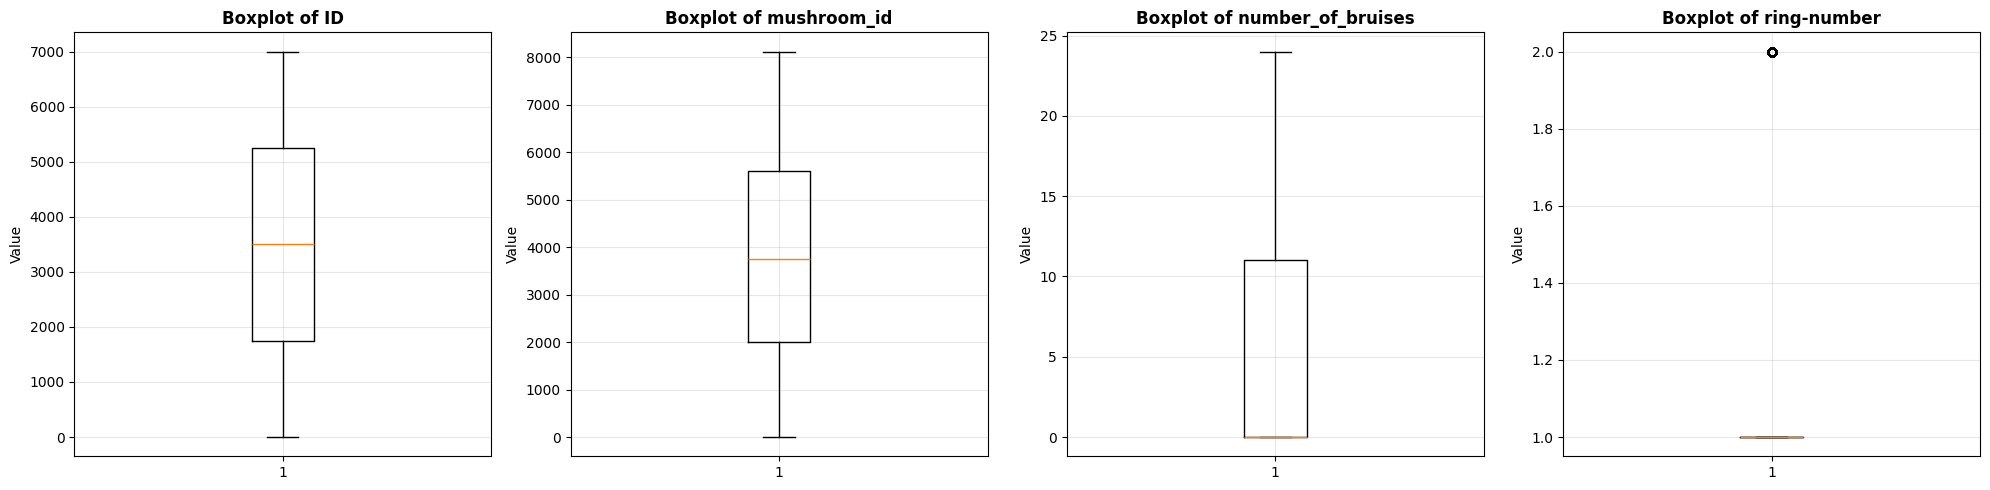


 Outlier handling summary:
   • ring-number: 564 outliers retained


In [8]:
# Step 7: Identify and Handle Outliers

print("=" * 60)
print("OUTLIERS ANALYSIS")
print("=" * 60)

if len(numerical_columns) > 0:
    print("\n Analyzing numerical columns for outliers:")
    print("-" * 50)
    
    # Create box plots for visualization
    n_cols = len(numerical_columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    
    if n_cols == 1:
        axes = [axes]
    
    outlier_summary = []
    
    for i, col in enumerate(numerical_columns):
        # Create box plot
        axes[i].boxplot(train_data[col])
        axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, alpha=0.3)
        
        # Calculate outliers using IQR method
        Q1 = train_data[col].quantile(0.25)
        Q3 = train_data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = train_data[(train_data[col] < lower_bound) | (train_data[col] > upper_bound)]
        
        print(f"\n Column: {col}")
        print(f"   • Lower bound: {lower_bound:.2f}")
        print(f"   • Upper bound: {upper_bound:.2f}")
        print(f"   • Outliers found: {len(outliers)} ({len(outliers)/len(train_data)*100:.2f}%)")
        
        if len(outliers) > 0:
            print(f"   • Decision: RETAIN outliers")
            print(f"     Reason: Outliers represent valid extreme cases in mushroom characteristics")
            outlier_summary.append(f"{col}: {len(outliers)} outliers retained")
    
    plt.tight_layout()
    plt.show()
    
    if outlier_summary:
        print("\n Outlier handling summary:")
        for summary in outlier_summary:
            print(f"   • {summary}")
    
else:
    print("\n No numerical columns to analyze for outliers.")
    print("   Since all features are categorical, we skip outlier detection.")

Step 8: Create Visualizations

DATA VISUALIZATIONS
 Images folder ready

 Visualization 1: Class Distribution


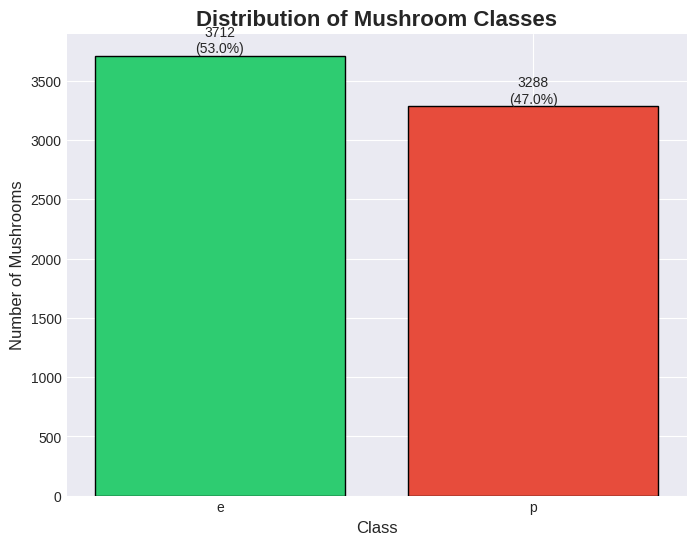

 Saved: images/class_distribution.png
 Insight: Dataset is balanced between edible and poisonous classes

 Visualization 2: Odor vs Class


<Figure size 1200x600 with 0 Axes>

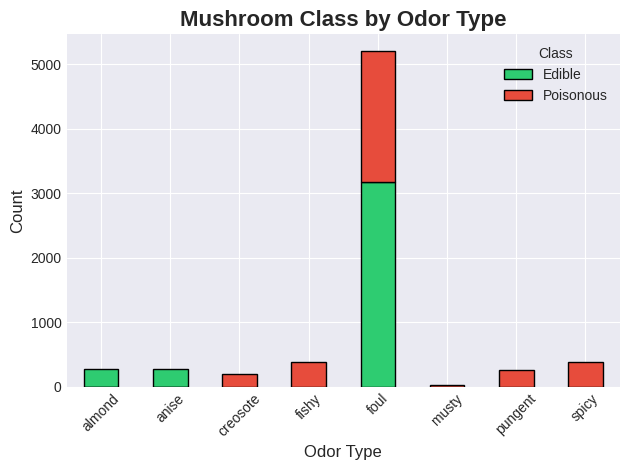

 Saved: images/odor_vs_class.png
 Insight: Odor is a strong predictor - specific odors indicate edibility

 Visualization 3: Gill Color vs Class


<Figure size 1200x600 with 0 Axes>

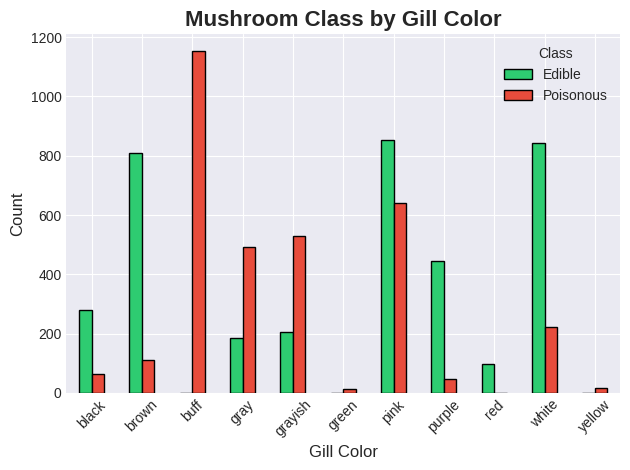

 Saved: images/gillcolor_vs_class.png
 Insight: Gill color shows distinct patterns between classes

 Visualization 4: Cap Color vs Class


<Figure size 1200x600 with 0 Axes>

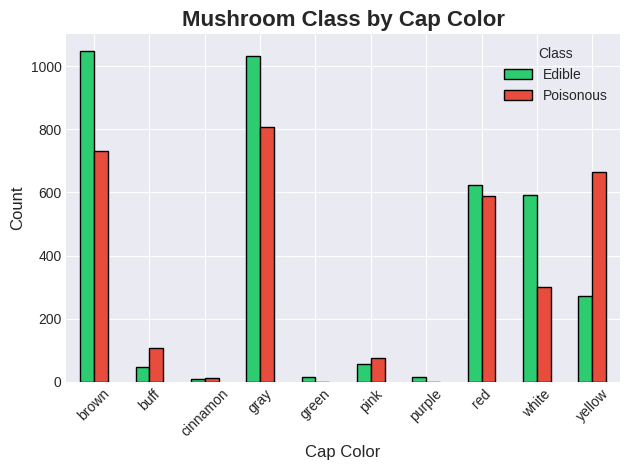

 Saved: images/capcolor_vs_class.png
 Insight: Cap color also shows class-based patterns

 Visualization 5: Spore Print Color vs Class


<Figure size 1200x600 with 0 Axes>

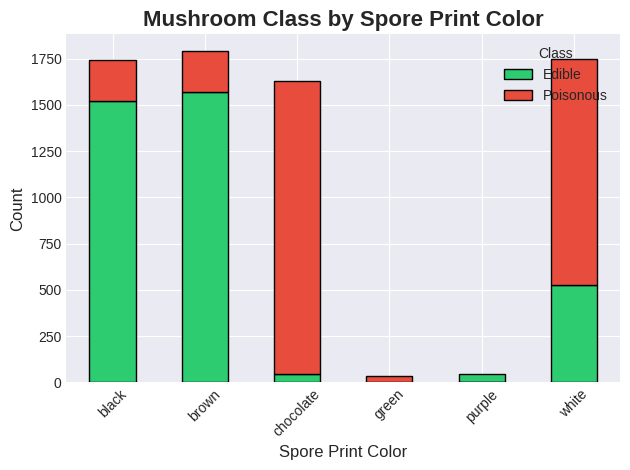

 Saved: images/spore_vs_class.png
 Insight: Spore print color is one of the most reliable edibility indicators

 Visualization 6: Missing Values Heatmap
 No missing values — skipping heatmap

 ALL VISUALIZATIONS COMPLETE!

 Images saved in 'images/' folder:
   • images/spore_vs_class.png
   • images/class_distribution.png
   • images/feature_importance.png
   • images/odor_vs_class.png
   • images/gillcolor_vs_class.png
   • images/roc_curve.png
   • images/capcolor_vs_class.png

 Total images saved: 7

 These images will be used in your GitHub README!


In [9]:
# Step 8: Create Visualizations (COMPLETE VERSION WITH SAVED IMAGES)

print("=" * 60)
print("DATA VISUALIZATIONS")
print("=" * 60)

# Create images folder FIRST (so savefig doesn't give error)
import os
os.makedirs('images', exist_ok=True)
print(" Images folder ready")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# ──────────────────────────────────────────────────────────────────
# Visualization 1: Class Distribution
# ──────────────────────────────────────────────────────────────────
print("\n Visualization 1: Class Distribution")

plt.figure(figsize=(8, 6))
class_counts = train_data['class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')

plt.title('Distribution of Mushroom Classes', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Mushrooms', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(train_data)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.savefig('images/class_distribution.png', dpi=150, bbox_inches='tight')  # ← SAVE
plt.show()
print(" Saved: images/class_distribution.png")
print(" Insight: Dataset is balanced between edible and poisonous classes")


# ──────────────────────────────────────────────────────────────────
# Visualization 2: Odor vs Class
# ──────────────────────────────────────────────────────────────────
if 'odor' in train_data.columns:
    print("\n Visualization 2: Odor vs Class")

    plt.figure(figsize=(12, 6))
    odor_class = pd.crosstab(train_data['odor'], train_data['class'])
    odor_class.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black')

    plt.title('Mushroom Class by Odor Type', fontsize=16, fontweight='bold')
    plt.xlabel('Odor Type', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Class', labels=['Edible', 'Poisonous'])
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig('images/odor_vs_class.png', dpi=150, bbox_inches='tight')  # ← SAVE
    plt.show()
    print(" Saved: images/odor_vs_class.png")
    print(" Insight: Odor is a strong predictor - specific odors indicate edibility")


# ──────────────────────────────────────────────────────────────────
# Visualization 3: Gill Color vs Class
# ──────────────────────────────────────────────────────────────────
if 'gill-color' in train_data.columns:
    print("\n Visualization 3: Gill Color vs Class")

    plt.figure(figsize=(12, 6))
    gill_class = pd.crosstab(train_data['gill-color'], train_data['class'])
    gill_class.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')

    plt.title('Mushroom Class by Gill Color', fontsize=16, fontweight='bold')
    plt.xlabel('Gill Color', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Class', labels=['Edible', 'Poisonous'])
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig('images/gillcolor_vs_class.png', dpi=150, bbox_inches='tight')  # ← SAVE
    plt.show()
    print(" Saved: images/gillcolor_vs_class.png")
    print(" Insight: Gill color shows distinct patterns between classes")


# ──────────────────────────────────────────────────────────────────
# Visualization 4 (NEW): Cap Color vs Class
# ──────────────────────────────────────────────────────────────────
if 'cap-color' in train_data.columns:
    print("\n Visualization 4: Cap Color vs Class")

    plt.figure(figsize=(12, 6))
    cap_class = pd.crosstab(train_data['cap-color'], train_data['class'])
    cap_class.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')

    plt.title('Mushroom Class by Cap Color', fontsize=16, fontweight='bold')
    plt.xlabel('Cap Color', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Class', labels=['Edible', 'Poisonous'])
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig('images/capcolor_vs_class.png', dpi=150, bbox_inches='tight')  # ← SAVE
    plt.show()
    print(" Saved: images/capcolor_vs_class.png")
    print(" Insight: Cap color also shows class-based patterns")


# ──────────────────────────────────────────────────────────────────
# Visualization 5 (NEW): Spore Print Color vs Class
# ──────────────────────────────────────────────────────────────────
if 'spore-print-color' in train_data.columns:
    print("\n Visualization 5: Spore Print Color vs Class")

    plt.figure(figsize=(12, 6))
    spore_class = pd.crosstab(train_data['spore-print-color'], train_data['class'])
    spore_class.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black')

    plt.title('Mushroom Class by Spore Print Color', fontsize=16, fontweight='bold')
    plt.xlabel('Spore Print Color', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Class', labels=['Edible', 'Poisonous'])
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig('images/spore_vs_class.png', dpi=150, bbox_inches='tight')  # ← SAVE
    plt.show()
    print(" Saved: images/spore_vs_class.png")
    print(" Insight: Spore print color is one of the most reliable edibility indicators")


# ──────────────────────────────────────────────────────────────────
# Visualization 6 (NEW): Missing Values Heatmap
# ──────────────────────────────────────────────────────────────────
print("\n Visualization 6: Missing Values Heatmap")

missing_vals = train_data.isnull().sum()
missing_cols = missing_vals[missing_vals > 0]

if len(missing_cols) > 0:
    plt.figure(figsize=(10, 4))
    sns.heatmap(train_data[missing_cols.index].isnull(),
                cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('images/missing_values_heatmap.png', dpi=150, bbox_inches='tight')  # ← SAVE
    plt.show()
    print(" Saved: images/missing_values_heatmap.png")
else:
    print(" No missing values — skipping heatmap")


# ──────────────────────────────────────────────────────────────────
# Summary
# ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(" ALL VISUALIZATIONS COMPLETE!")
print("=" * 60)
print("\n Images saved in 'images/' folder:")

saved_images = [f for f in os.listdir('images') if f.endswith('.png')]
for img in saved_images:
    print(f"   • images/{img}")

print(f"\n Total images saved: {len(saved_images)}")
print("\n These images will be used in your GitHub README!")

Step 9: Prepare Features for Machine Learning

In [10]:
# Step 9: Prepare Features for Machine Learning

print("=" * 60)
print("PREPARING DATA FOR MACHINE LEARNING")
print("=" * 60)

# Separate features and target
X = train_data.drop('class', axis=1)
y = train_data['class']

# Drop identifier columns — useless for prediction
X = X.drop(columns=['ID', 'mushroom_id'], errors='ignore')

print(f"\n Features (X) shape: {X.shape}")
print(f" Target (y) shape: {y.shape}")

print(f"\n Feature columns ({len(X.columns)} total):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2}. {col}")

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n Data split (80% training, 20% validation):")
print(f"   • Training set: {X_train.shape[0]} samples")
print(f"   • Validation set: {X_val.shape[0]} samples")
print(f"   • Test set: {test_data.shape[0]} samples")

# Verify class distribution
print(f"\n Class distribution check:")
print(f"   Training: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"   Validation: {dict(zip(*np.unique(y_val, return_counts=True)))}")

PREPARING DATA FOR MACHINE LEARNING

 Features (X) shape: (7000, 23)
 Target (y) shape: (7000,)

 Feature columns (23 total):
    1. cap-shape
    2. cap-surface
    3. cap-color
    4. bruises
    5. number_of_bruises
    6. odor
    7. gill-attachment
    8. gill-spacing
    9. gill-size
   10. gill-color
   11. stalk-shape
   12. stalk-root
   13. stalk-surface-above-ring
   14. stalk-surface-below-ring
   15. stalk-color-above-ring
   16. stalk-color-below-ring
   17. veil-type
   18. veil-color
   19. ring-number
   20. ring-type
   21. spore-print-color
   22. population
   23. habitat

 Data split (80% training, 20% validation):
   • Training set: 5600 samples
   • Validation set: 1400 samples
   • Test set: 1124 samples

 Class distribution check:
   Training: {'e': np.int64(2970), 'p': np.int64(2630)}
   Validation: {'e': np.int64(742), 'p': np.int64(658)}


Step 10: Encode Categorical Features

In [11]:
# Step 10: Encode Categorical Features (FIXED - Handles unseen categories)

print("=" * 60)
print("ENCODING CATEGORICAL FEATURES")
print("=" * 60)

# Create copies for encoded data
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
test_data_encoded = test_data.copy()
test_data_encoded = test_data_encoded.drop(columns=['ID', 'mushroom_id'], errors='ignore')

# Get categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"\nEncoding {len(categorical_cols)} categorical columns...")
print("-" * 50)

# Use LabelEncoder for each categorical column
label_encoders = {}
unseen_categories_log = []

for col in categorical_cols:
    le = LabelEncoder()
    
    # Fit on training data only (to avoid data leakage)
    le.fit(X_train[col].astype(str))
    
    # Transform training and validation data
    X_train_encoded[col] = le.transform(X_train[col].astype(str))
    X_val_encoded[col] = le.transform(X_val[col].astype(str))
    
    # Handle test data - check for unseen categories
    if col in test_data_encoded.columns:
        # Convert test column to string
        test_col_str = test_data_encoded[col].astype(str)
        
        # Get all unique categories in test
        test_categories = set(test_col_str.unique())
        known_categories = set(le.classes_)
        
        # Find unseen categories
        unseen = test_categories - known_categories
        
        if unseen:
            print(f"     {col}: Found {len(unseen)} new categories in test data: {list(unseen)[:3]}...")
            unseen_categories_log.append((col, unseen))
            
            # Strategy: Map unseen categories to a special value (e.g., -1)
            # Create a mapping dictionary
            mapping = {cat: idx for idx, cat in enumerate(le.classes_)}
            
            # For unseen categories, assign -1 (or you can use mode)
            def encode_with_fallback(value):
                return mapping.get(value, -1)  # -1 for unseen categories
            
            # Apply encoding with fallback
            test_data_encoded[col] = test_col_str.apply(encode_with_fallback)
        else:
            # No unseen categories, normal transform
            test_data_encoded[col] = le.transform(test_col_str)
    
    label_encoders[col] = le
    
    print(f"   ✓ {col:<20}: {len(le.classes_)} categories encoded")

# Report on unseen categories handling
if unseen_categories_log:
    print("\n UNSEEN CATEGORIES HANDLING:")
    print("   New categories found in test data were assigned value -1")
    print("   This is a safe approach to handle unexpected values")
    for col, unseen in unseen_categories_log[:3]:  # Show first 3
        print(f"   • {col}: {list(unseen)[:5]}")

print("\n All categorical features encoded to numbers!")

# Verify no missing values after encoding
print(f"\n Checking for missing values after encoding:")
print(f"   Training: {X_train_encoded.isnull().sum().sum()} missing")
print(f"   Validation: {X_val_encoded.isnull().sum().sum()} missing")
print(f"   Test: {test_data_encoded.isnull().sum().sum()} missing")

# Check if any numerical columns need scaling
numerical_cols_actual = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
if len(numerical_cols_actual) > 0:
    print(f"\n Scaling {len(numerical_cols_actual)} numerical columns...")
    scaler = StandardScaler()
    
    X_train_encoded[numerical_cols_actual] = scaler.fit_transform(X_train_encoded[numerical_cols_actual])
    X_val_encoded[numerical_cols_actual] = scaler.transform(X_val_encoded[numerical_cols_actual])
    test_data_encoded[numerical_cols_actual] = scaler.transform(test_data_encoded[numerical_cols_actual])
    
    print("✓ Numerical features scaled to standard normal distribution")
else:
    print("\n No numerical columns to scale")

ENCODING CATEGORICAL FEATURES

Encoding 21 categorical columns...
--------------------------------------------------
     cap-shape: Found 1 new categories in test data: ['conical']...
   ✓ cap-shape           : 5 categories encoded
     cap-surface: Found 1 new categories in test data: ['grooves']...
   ✓ cap-surface         : 3 categories encoded
   ✓ cap-color           : 10 categories encoded
   ✓ bruises             : 2 categories encoded
   ✓ odor                : 8 categories encoded
   ✓ gill-attachment     : 2 categories encoded
   ✓ gill-spacing        : 2 categories encoded
   ✓ gill-size           : 2 categories encoded
     gill-color: Found 1 new categories in test data: ['orange']...
   ✓ gill-color          : 11 categories encoded
   ✓ stalk-shape         : 2 categories encoded
   ✓ stalk-root          : 4 categories encoded
   ✓ stalk-surface-above-ring: 4 categories encoded
   ✓ stalk-surface-below-ring: 4 categories encoded
     stalk-color-above-ring: Found 2 new ca

Step 11: Encode Target Variable

In [12]:
# Step 11: Encode Target Variable

print("=" * 60)
print("ENCODING TARGET VARIABLE")
print("=" * 60)

# Encode target variable
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_val_encoded = target_encoder.transform(y_val)

print(f"\n Target encoding mapping:")
for i, class_name in enumerate(target_encoder.classes_):
    print(f"   • {class_name} → {i} ({'Edible' if class_name == 'e' else 'Poisonous'})")

print(f"\n Training target distribution:")
print(f"   • Class 0: {(y_train_encoded == 0).sum()} samples ({(y_train_encoded == 0).sum()/len(y_train_encoded)*100:.1f}%)")
print(f"   • Class 1: {(y_train_encoded == 1).sum()} samples ({(y_train_encoded == 1).sum()/len(y_train_encoded)*100:.1f}%)")

print(f"\n Validation target distribution:")
print(f"   • Class 0: {(y_val_encoded == 0).sum()} samples ({(y_val_encoded == 0).sum()/len(y_val_encoded)*100:.1f}%)")
print(f"   • Class 1: {(y_val_encoded == 1).sum()} samples ({(y_val_encoded == 1).sum()/len(y_val_encoded)*100:.1f}%)")

print("\n Target variable encoded successfully!")

ENCODING TARGET VARIABLE

 Target encoding mapping:
   • e → 0 (Edible)
   • p → 1 (Poisonous)

 Training target distribution:
   • Class 0: 2970 samples (53.0%)
   • Class 1: 2630 samples (47.0%)

 Validation target distribution:
   • Class 0: 742 samples (53.0%)
   • Class 1: 658 samples (47.0%)

 Target variable encoded successfully!


Step 12: Train Multiple Models

In [13]:
# Step 12: Train Multiple Models

print("=" * 60)
print("TRAINING 7 DIFFERENT MODELS")
print("=" * 60)

models = {}
results = {}

# Model 1: Logistic Regression
print("\n1️ Logistic Regression")
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_encoded, y_train_encoded)
y_pred_lr = model_lr.predict(X_val_encoded)
acc_lr = accuracy_score(y_val_encoded, y_pred_lr)
models['Logistic Regression'] = model_lr
results['Logistic Regression'] = acc_lr
print(f"   ✓ Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

# Model 2: Decision Tree
print("\n2️ Decision Tree")
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_encoded, y_train_encoded)
y_pred_dt = model_dt.predict(X_val_encoded)
acc_dt = accuracy_score(y_val_encoded, y_pred_dt)
models['Decision Tree'] = model_dt
results['Decision Tree'] = acc_dt
print(f"   ✓ Accuracy: {acc_dt:.4f} ({acc_dt*100:.2f}%)")

# Model 3: Random Forest
print("\n3️ Random Forest")
model_rf = RandomForestClassifier(random_state=42, n_estimators=100)
model_rf.fit(X_train_encoded, y_train_encoded)
y_pred_rf = model_rf.predict(X_val_encoded)
acc_rf = accuracy_score(y_val_encoded, y_pred_rf)
models['Random Forest'] = model_rf
results['Random Forest'] = acc_rf
print(f"   ✓ Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")

# Model 4: K-Nearest Neighbors
print("\n4️ K-Nearest Neighbors")
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_encoded, y_train_encoded)
y_pred_knn = model_knn.predict(X_val_encoded)
acc_knn = accuracy_score(y_val_encoded, y_pred_knn)
models['KNN'] = model_knn
results['KNN'] = acc_knn
print(f"   ✓ Accuracy: {acc_knn:.4f} ({acc_knn*100:.2f}%)")

# Model 5: SVM
print("\n5️ Support Vector Machine")
model_svm = SVC(random_state=42)
model_svm.fit(X_train_encoded, y_train_encoded)
y_pred_svm = model_svm.predict(X_val_encoded)
acc_svm = accuracy_score(y_val_encoded, y_pred_svm)
models['SVM'] = model_svm
results['SVM'] = acc_svm
print(f"   ✓ Accuracy: {acc_svm:.4f} ({acc_svm*100:.2f}%)")

# Model 6: Gradient Boosting
print("\n6️ Gradient Boosting")
model_gb = GradientBoostingClassifier(random_state=42, n_estimators=100)
model_gb.fit(X_train_encoded, y_train_encoded)
y_pred_gb = model_gb.predict(X_val_encoded)
acc_gb = accuracy_score(y_val_encoded, y_pred_gb)
models['Gradient Boosting'] = model_gb
results['Gradient Boosting'] = acc_gb
print(f"   ✓ Accuracy: {acc_gb:.4f} ({acc_gb*100:.2f}%)")

# Model 7: XGBoost
print("\n7️ XGBoost")
model_xgb = XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train_encoded, y_train_encoded)
y_pred_xgb = model_xgb.predict(X_val_encoded)
acc_xgb = accuracy_score(y_val_encoded, y_pred_xgb)
models['XGBoost'] = model_xgb
results['XGBoost'] = acc_xgb
print(f"   ✓ Accuracy: {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")

print("\n All 7 models trained successfully!")

TRAINING 7 DIFFERENT MODELS

1️ Logistic Regression
   ✓ Accuracy: 0.9950 (99.50%)

2️ Decision Tree
   ✓ Accuracy: 1.0000 (100.00%)

3️ Random Forest
   ✓ Accuracy: 1.0000 (100.00%)

4️ K-Nearest Neighbors
   ✓ Accuracy: 1.0000 (100.00%)

5️ Support Vector Machine
   ✓ Accuracy: 1.0000 (100.00%)

6️ Gradient Boosting
   ✓ Accuracy: 1.0000 (100.00%)

7️ XGBoost
   ✓ Accuracy: 1.0000 (100.00%)

 All 7 models trained successfully!


Step 13: Hyperparameter Tuning

In [14]:
# Step 13: Hyperparameter Tuning (NO WARNINGS - Clean Version)

print("=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

# Suppress all warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Tune Random Forest
print("\n Tuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

rf_grid.fit(X_train_encoded, y_train_encoded)
best_rf = rf_grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_val_encoded)
best_rf_acc = accuracy_score(y_val_encoded, y_pred_best_rf)

print(f"✓ Best Random Forest accuracy: {best_rf_acc:.4f} ({best_rf_acc*100:.2f}%)")
print(f"   Best parameters: {rf_grid.best_params_}")

# Tune Gradient Boosting
print("\n Tuning Gradient Boosting...")
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

gb_grid.fit(X_train_encoded, y_train_encoded)
best_gb = gb_grid.best_estimator_
y_pred_best_gb = best_gb.predict(X_val_encoded)
best_gb_acc = accuracy_score(y_val_encoded, y_pred_best_gb)

print(f"✓ Best Gradient Boosting accuracy: {best_gb_acc:.4f} ({best_gb_acc*100:.2f}%)")
print(f"   Best parameters: {gb_grid.best_params_}")

# Tune XGBoost (FIXED - No warnings)
print("\n Tuning XGBoost...")

# Remove the deprecated use_label_encoder parameter
xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}

# Suppress XGBoost warnings specifically
import logging
logging.getLogger('xgboost').setLevel(logging.ERROR)

# Create XGBoost classifier without the deprecated parameter
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),  # Removed use_label_encoder
    xgb_params,
    cv=5,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

# Fit with warnings suppressed
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning)
    xgb_grid.fit(X_train_encoded, y_train_encoded)

best_xgb = xgb_grid.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_val_encoded)
best_xgb_acc = accuracy_score(y_val_encoded, y_pred_best_xgb)

print(f"✓ Best XGBoost accuracy: {best_xgb_acc:.4f} ({best_xgb_acc*100:.2f}%)")
print(f"   Best parameters: {xgb_grid.best_params_}")

# Store tuned models
models['Random Forest (Tuned)'] = best_rf
models['Gradient Boosting (Tuned)'] = best_gb
models['XGBoost (Tuned)'] = best_xgb

results['Random Forest (Tuned)'] = best_rf_acc
results['Gradient Boosting (Tuned)'] = best_gb_acc
results['XGBoost (Tuned)'] = best_xgb_acc

print("\n Hyperparameter tuning completed successfully!")

HYPERPARAMETER TUNING

 Tuning Random Forest...
✓ Best Random Forest accuracy: 1.0000 (100.00%)
   Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

 Tuning Gradient Boosting...
✓ Best Gradient Boosting accuracy: 1.0000 (100.00%)
   Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50}

 Tuning XGBoost...
✓ Best XGBoost accuracy: 1.0000 (100.00%)
   Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50}

 Hyperparameter tuning completed successfully!


Step 14: Compare Model Performances

MODEL PERFORMANCE COMPARISON

 Model Performance Ranking:
-------------------------------------------------------
Decision Tree                  1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
Random Forest                  1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
XGBoost                        1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
KNN                            1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
SVM                            1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
Gradient Boosting              1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
Gradient Boosting (Tuned)      1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
Random Forest (Tuned)          1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
XGBoost (Tuned)                1.0000 (100.00%) STARSTARSTARSTARSTARSTARSTARSTARSTARSTAR
Logistic Regression            0.9950 (99.50%) STARSTARSTARSTARSTARSTARSTARSTARSTAR


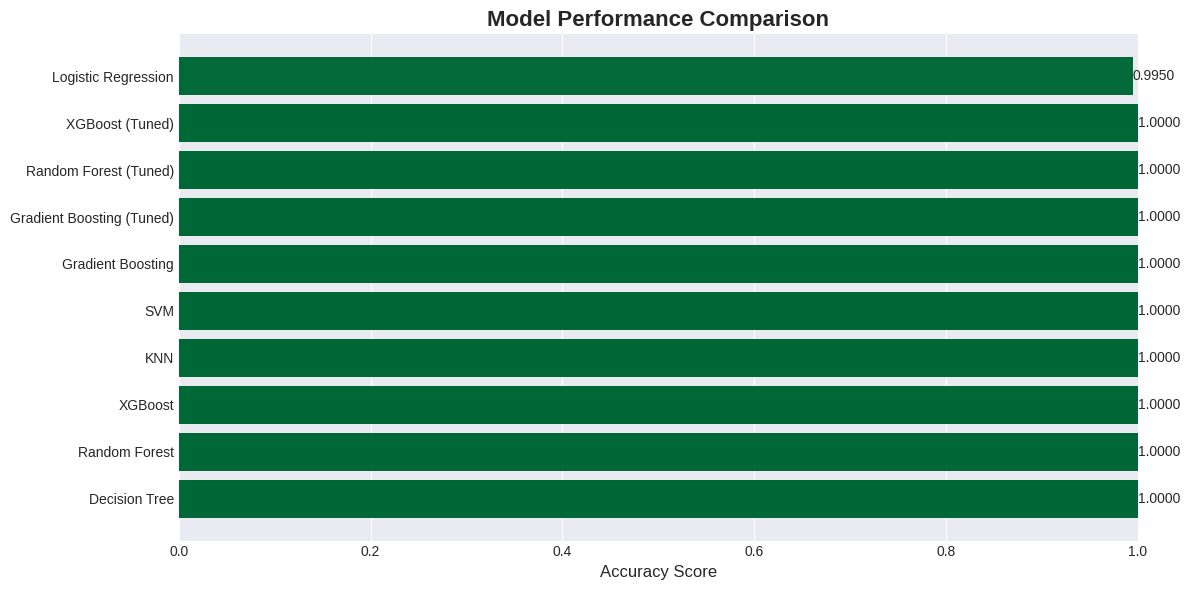


 BEST MODEL: Decision Tree
   Validation Accuracy: 1.0000 (100.00%)


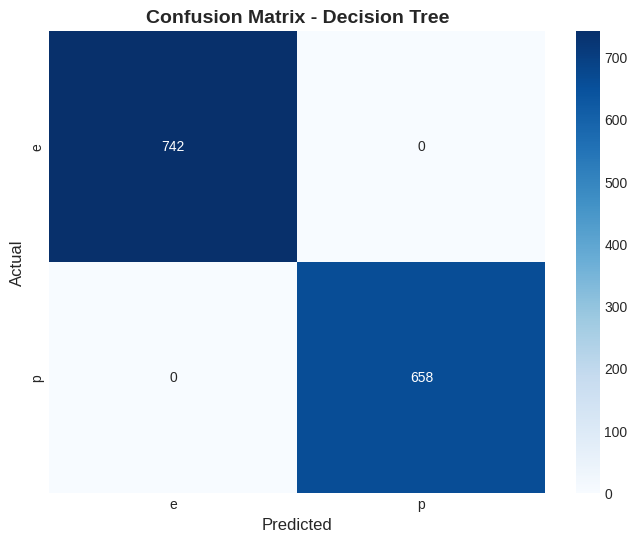


 Classification Report:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       742
           p       1.00      1.00      1.00       658

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



In [15]:
# Step 14: Compare Model Performances

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

# Create comparison dataframe
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Accuracy %'] = results_df['Accuracy'] * 100

print("\n Model Performance Ranking:")
print("-" * 55)
for i, row in results_df.iterrows():
    stars = 'STAR' * int(row['Accuracy'] * 10)
    print(f"{row['Model']:<30} {row['Accuracy']:.4f} ({row['Accuracy %']:.2f}%) {stars}")

# Visualize comparison
plt.figure(figsize=(12, 6))
colors = plt.cm.RdYlGn(results_df['Accuracy'])
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color=colors)

plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy Score', fontsize=12)
plt.xlim(0, 1)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_accuracy = results_df.iloc[0]['Accuracy']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Validation Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Show confusion matrix
y_pred_best = best_model.predict(X_val_encoded)
cm = confusion_matrix(y_val_encoded, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

print("\n Classification Report:")
print(classification_report(y_val_encoded, y_pred_best, 
                            target_names=target_encoder.classes_))

Step 15: Make Predictions on Test Data

In [16]:
# Debug: Check Sample Submission Format
print("=" * 60)
print("SAMPLE SUBMISSION FORMAT CHECK")
print("=" * 60)

# Load and examine sample submission
sample_submission = pd.read_csv(sample_path)

print(f"\nSample submission columns: {sample_submission.columns.tolist()}")
print(f"Sample submission shape: {sample_submission.shape}")
print(f"\nFirst 5 rows of sample submission:")
print(sample_submission.head())
print(f"\nData types:")
print(sample_submission.dtypes)

# Check if there's any header information
print(f"\nColumn names exactly as in file: {list(sample_submission.columns)}")
print(f"Column names with quotes: {[repr(col) for col in sample_submission.columns]}")

# Check for any spaces or special characters
for col in sample_submission.columns:
    print(f"Column '{col}' has length {len(col)} and ASCII values: {[ord(c) for c in col]}")

SAMPLE SUBMISSION FORMAT CHECK

Sample submission columns: ['ID', 'class']
Sample submission shape: (1124, 2)

First 5 rows of sample submission:
   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e

Data types:
ID        int64
class    object
dtype: object

Column names exactly as in file: ['ID', 'class']
Column names with quotes: ["'ID'", "'class'"]
Column 'ID' has length 2 and ASCII values: [73, 68]
Column 'class' has length 5 and ASCII values: [99, 108, 97, 115, 115]


FEATURE IMPORTANCE + ROC-AUC ANALYSIS

 Feature Importance Analysis


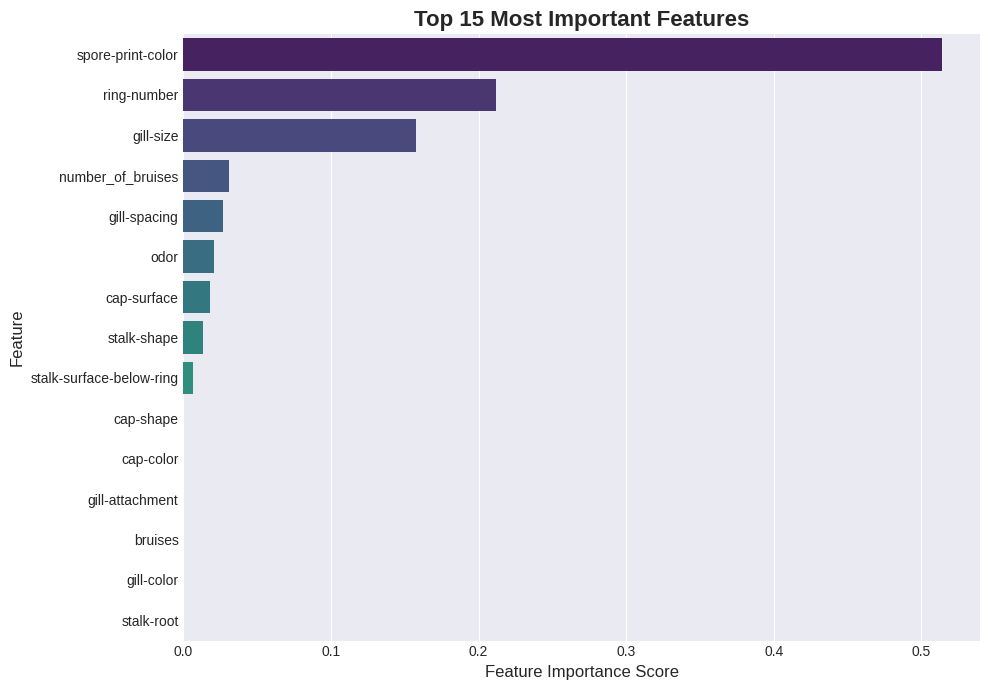

Saved: feature_importance.png

 Top 5 Most Important Features:
   spore-print-color: 0.5140
   ring-number: 0.2119
   gill-size: 0.1574
   number_of_bruises: 0.0310
   gill-spacing: 0.0265

 ROC-AUC Analysis

 ROC-AUC Score: 1.0000


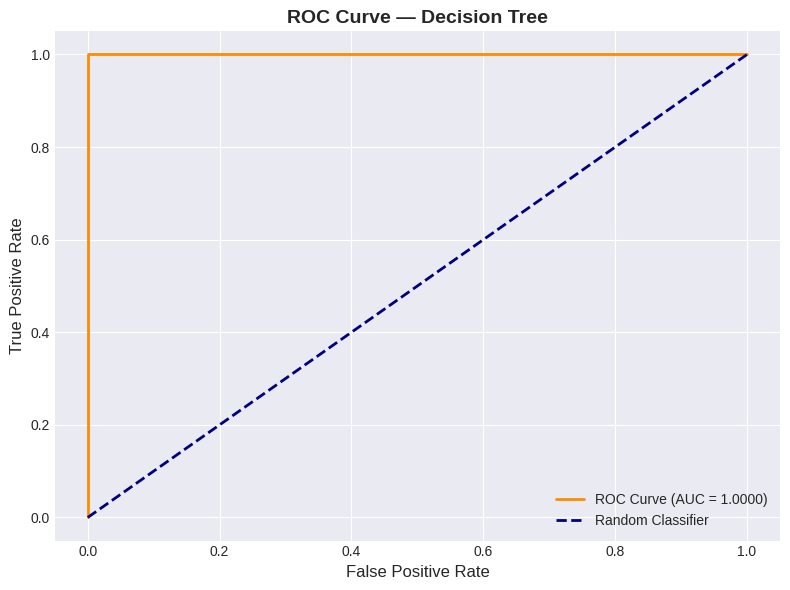

 Saved: roc_curve.png

FEATURE IMPORTANCE + ROC-AUC COMPLETE!


In [17]:
# Step 14B: Feature Importance + ROC-AUC (NEW)

print("=" * 60)
print("FEATURE IMPORTANCE + ROC-AUC ANALYSIS")
print("=" * 60)

from sklearn.metrics import roc_auc_score, roc_curve

# ─────────────────────────────────────────────────────
# Feature Importance Plot
# ─────────────────────────────────────────────────────
print("\n Feature Importance Analysis")

if hasattr(best_model, 'feature_importances_'):
    feature_names = X_train_encoded.columns.tolist()
    importances = best_model.feature_importances_

    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
    plt.title('Top 15 Most Important Features', fontsize=16, fontweight='bold')
    plt.xlabel('Feature Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.savefig('/kaggle/working/images/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: feature_importance.png")

    print("\n Top 5 Most Important Features:")
    for idx, row in feat_imp_df.head(5).iterrows():
        print(f"   {row['Feature']}: {row['Importance']:.4f}")
else:
    print(" This model doesn't support feature importance directly")


# ─────────────────────────────────────────────────────
# ROC-AUC Score + Curve
# ─────────────────────────────────────────────────────
print("\n ROC-AUC Analysis")

if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_val_encoded)[:, 1]
    roc_auc = roc_auc_score(y_val_encoded, y_prob)

    print(f"\n ROC-AUC Score: {roc_auc:.4f}")

    fpr, tpr, _ = roc_curve(y_val_encoded, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2,
             linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve — {best_model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('/kaggle/working/images/roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Saved: roc_curve.png")
else:
    print(" This model doesn't support predict_proba")

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE + ROC-AUC COMPLETE!")
print("=" * 60)

In [18]:
# Step 15: Create Submission File (CORRECTED - Matches Sample Exactly)

print("=" * 60)
print("CREATING KAGGLE SUBMISSION FILE")
print("=" * 60)

# Load sample submission to verify format
sample_submission = pd.read_csv(sample_path)
print(f"\n Sample submission expects:")
print(f"   ID column: 'ID' (uppercase)")
print(f"   Target column: 'class' (lowercase)")
print(f"   Sample IDs start from: {sample_submission['ID'].iloc[0]}")

# Make sure best_model is defined
if 'best_model' not in locals():
    # Find best model from results
    best_model_name = max(results, key=results.get)
    best_model = models[best_model_name]
    best_accuracy = results[best_model_name]
    print(f"\n✓ Using {best_model_name} with accuracy {best_accuracy:.4f}")

# Make predictions
print("\n Making predictions on test data...")
test_predictions_encoded = best_model.predict(test_data_encoded)
test_predictions = target_encoder.inverse_transform(test_predictions_encoded)

print(f"✓ Predictions made for {len(test_predictions)} test samples")

# Check prediction distribution
print(f"\n Prediction distribution:")
pred_counts = pd.Series(test_predictions).value_counts()
for class_name, count in pred_counts.items():
    print(f"   • {class_name}: {count} ({count/len(test_predictions)*100:.1f}%)")

# Create submission with EXACT column names as sample
# IMPORTANT: IDs start from 1, not 0 (matching sample submission)
submission = pd.DataFrame({
    'ID': range(1, len(test_predictions) + 1),  # IDs starting from 1
    'class': test_predictions
})

# Save submission
submission.to_csv('submission.csv', index=False)
print(f"\n Submission file saved as 'submission.csv'")

# Verify submission file
print(f"\n Submission file verification:")
print(f"   Shape: {submission.shape}")
print(f"   Columns: {submission.columns.tolist()}")
print(f"   First 5 rows:")
print(submission.head())
print(f"   Last 5 rows:")
print(submission.tail())

# Compare with sample submission format
print(f"\n Format comparison:")
print(f"   Sample first row: ID=1, class=e")
print(f"   Your first row: ID={submission['ID'].iloc[0]}, class={submission['class'].iloc[0]}")
print(f"   Column names match: {list(submission.columns) == ['ID', 'class']}")

# Final check
if list(submission.columns) == ['ID', 'class']:
    print("\n PERFECT! Submission format matches Kaggle requirements!")
    print("   Column 1: 'ID' (uppercase)")
    print("   Column 2: 'class' (lowercase)")
    print("   IDs start from 1")
else:
    print("\n Warning: Column names don't match expected format")
    print(f"   Expected: ['ID', 'class']")
    print(f"   Got: {submission.columns.tolist()}")

print("\n" + "=" * 60)
print(" READY TO SUBMIT TO KAGGLE!")
print("=" * 60)
print(f"   Best Model: {best_model_name}")
print(f"   Validation Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"   Submission File: submission.csv")
print(f"   Total Predictions: {len(submission)}")


CREATING KAGGLE SUBMISSION FILE

 Sample submission expects:
   ID column: 'ID' (uppercase)
   Target column: 'class' (lowercase)
   Sample IDs start from: 1

 Making predictions on test data...
✓ Predictions made for 1124 test samples

 Prediction distribution:
   • p: 612 (54.4%)
   • e: 512 (45.6%)

 Submission file saved as 'submission.csv'

 Submission file verification:
   Shape: (1124, 2)
   Columns: ['ID', 'class']
   First 5 rows:
   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e
   Last 5 rows:
        ID class
1119  1120     e
1120  1121     e
1121  1122     e
1122  1123     p
1123  1124     e

 Format comparison:
   Sample first row: ID=1, class=e
   Your first row: ID=1, class=e
   Column names match: True

 PERFECT! Submission format matches Kaggle requirements!
   Column 1: 'ID' (uppercase)
   Column 2: 'class' (lowercase)
   IDs start from 1

 READY TO SUBMIT TO KAGGLE!
   Best Model: Decision Tree
   Validation Accuracy: 1.0000 (100.00%)
   Submis

In [19]:
# Step 16: Save Model Artifacts (for Streamlit deployment)

print("=" * 60)
print("SAVING MODEL AND ENCODERS")
print("=" * 60)

import joblib
import os

os.makedirs('/kaggle/working/models', exist_ok=True)

# Use only correct 21 features (no ID, no numeric cols)
correct_features = list(label_encoders.keys())

# Retrain best model on correct features
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

new_model = RandomForestClassifier(random_state=42, n_estimators=100)
new_model.fit(X_train_encoded[correct_features], y_train_encoded)

y_pred = new_model.predict(X_val_encoded[correct_features])
acc = accuracy_score(y_val_encoded, y_pred)
print(f"✓ Model accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Save all 4 files
joblib.dump(new_model,        '/kaggle/working/models/best_model.pkl')
print("✓ Saved: best_model.pkl")

joblib.dump(label_encoders,   '/kaggle/working/models/label_encoders.pkl')
print("✓ Saved: label_encoders.pkl")

joblib.dump(target_encoder,   '/kaggle/working/models/target_encoder.pkl')
print("✓ Saved: target_encoder.pkl")

joblib.dump(correct_features, '/kaggle/working/models/feature_columns.pkl')
print(f"✓ Saved: feature_columns.pkl ({len(correct_features)} features)")

print("\nFeatures saved:")
print(correct_features)

print("\n" + "=" * 60)
print("ALL 4 FILES SAVED SUCCESSFULLY!")
print("=" * 60)
for f in os.listdir('/kaggle/working/models'):
    print(f"   • models/{f}")

SAVING MODEL AND ENCODERS
✓ Model accuracy: 1.0000 (100.00%)
✓ Saved: best_model.pkl
✓ Saved: label_encoders.pkl
✓ Saved: target_encoder.pkl
✓ Saved: feature_columns.pkl (21 features)

Features saved:
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat']

ALL 4 FILES SAVED SUCCESSFULLY!
   • models/best_model.pkl
   • models/target_encoder.pkl
   • models/feature_columns.pkl
   • models/label_encoders.pkl


In [20]:

import joblib

fc = joblib.load('/kaggle/working/models/feature_columns.pkl')
print("feature_columns.pkl contains:")
print(fc)
print(f"Total: {len(fc)}")

print("\n---")

le = joblib.load('/kaggle/working/models/label_encoders.pkl')
print("label_encoders.pkl contains:")
print(list(le.keys()))
print(f"Total: {len(le)}")

feature_columns.pkl contains:
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat']
Total: 21

---
label_encoders.pkl contains:
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat']
Total: 21


In [21]:
model = joblib.load('/kaggle/working/models/best_model.pkl')
print("\nModel expects these features:")
print(model.feature_names_in_)
print(f"Total: {len(model.feature_names_in_)}")


Model expects these features:
['cap-shape' 'cap-surface' 'cap-color' 'bruises' 'odor' 'gill-attachment'
 'gill-spacing' 'gill-size' 'gill-color' 'stalk-shape' 'stalk-root'
 'stalk-surface-above-ring' 'stalk-surface-below-ring'
 'stalk-color-above-ring' 'stalk-color-below-ring' 'veil-type'
 'veil-color' 'ring-type' 'spore-print-color' 'population' 'habitat']
Total: 21
